In [1]:
# ============ 셀 1: 설정 (L3: Muon 사전학습 → Muon 파인튜닝) ============
import os, json, time, math, random, glob, shutil, copy
import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.nn.attention import sdpa_kernel, SDPBackend

assert torch.cuda.is_available(), "GPU가 꺼져 있어요. Settings → Accelerator → GPU T4 로 바꾸세요."
DEV = 'cuda'

OUT  = '/kaggle/working/exp_llm_muon_ftmuon'
DATA = '/tmp/llm_data'
os.makedirs(OUT, exist_ok=True); os.makedirs(DATA, exist_ok=True)

CFG = dict(
    seed=0, ctx=256, vocab=50304,
    d_model=512, n_layer=6, n_head=8,
    pre_epochs=10, pre_bs=32, pre_wd=0.1, grad_clip=1.0,
    muon_momentum=0.95, ns_steps=5,
    # 파인튜닝: Muon(블록 안 행렬) + 보조 AdamW(임베딩·LayerNorm·bias)
    ft_muon_div=[10, 3],              # Muon lr = L2 사전학습 Muon 최적 lr ÷ 10, ÷ 3
    ft_adam_lrs=[1e-4, 1e-3 / 3],     # 보조 AdamW lr = L1·L2 파인튜닝 lr과 동일
    ft_steps=1000, ft_bs=32, ft_wd=0.1, ft_warmup=50, ft_seeds=[0, 1, 2], ft_eval_every=100,
    code_files=10000, code_max_chars=20000,
    eval_seqs=400, eval_bs=32, hvp_iters=20,
)
json.dump(CFG, open(f'{OUT}/config.json', 'w'), indent=2)

def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)

print('GPU :', torch.cuda.get_device_name(0), '| torch', torch.__version__)

GPU : Tesla T4 | torch 2.10.0+cu128


In [2]:
# ============ 셀 2: BabyLM + 파이썬 코드 다운로드, 토큰화 (한 번만) ============
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained('gpt2'); tok.model_max_length = int(1e9)
EOS = tok.eos_token_id

def encode_texts(texts, bs=256):
    parts = []
    for i in range(0, len(texts), bs):
        for ids in tok(texts[i:i + bs])['input_ids']:
            parts.append(np.array(ids + [EOS], dtype=np.uint16))
    return np.concatenate(parts)

def chunk_lines(text, n=200):
    lines = text.split('\n')
    return ['\n'.join(lines[i:i + n]) for i in range(0, len(lines), n)]

# ---------- BabyLM ----------
if os.path.exists(f'{DATA}/babylm_val.npy'):
    print('BabyLM 토큰 파일이 이미 있음 → 건너뜀')
else:
    try:
        from huggingface_hub import snapshot_download
        root = snapshot_download('cambridge-climb/BabyLM', repo_type='dataset', allow_patterns=['10M/*', 'dev/*'])
        tr_files = sorted(f for f in glob.glob(f'{root}/10M/*') if os.path.isfile(f))
        dv_files = sorted(f for f in glob.glob(f'{root}/dev/*') if os.path.isfile(f))
        assert tr_files and dv_files, '파일 없음'
        tr_texts, dv_texts = [], []
        for f in tr_files: tr_texts += chunk_lines(open(f, encoding='utf-8', errors='ignore').read())
        for f in dv_files: dv_texts += chunk_lines(open(f, encoding='utf-8', errors='ignore').read()[:500_000])
        src = f'cambridge-climb/BabyLM (2023) | train 파일 {len(tr_files)}개, dev 파일 {len(dv_files)}개'
    except Exception as e:
        print('2023판 다운로드 실패 → 2026판으로 대체:', repr(e)[:200])
        from datasets import load_dataset
        ds = load_dataset('BabyLM-community/BabyLM-2026-Strict-Small', split='train')
        col = [c for c, t in ds.features.items() if getattr(t, 'dtype', None) == 'string'][0]
        lines = [t for t in ds[col] if t and t.strip()]
        idx = np.random.RandomState(0).permutation(len(lines)); nv = len(lines) // 20
        dv_lines = [lines[i] for i in idx[:nv]]; tr_lines = [lines[i] for i in idx[nv:]]
        tr_texts = ['\n'.join(tr_lines[i:i + 200]) for i in range(0, len(tr_lines), 200)]
        dv_texts = ['\n'.join(dv_lines[i:i + 200]) for i in range(0, len(dv_lines), 200)]
        src = 'BabyLM-community/BabyLM-2026-Strict-Small (5%를 검증용으로 분리)'
    print('BabyLM 출처:', src, flush=True)
    tr = encode_texts(tr_texts); dv = encode_texts(dv_texts)
    np.save(f'{DATA}/babylm_train.npy', tr); np.save(f'{DATA}/babylm_val.npy', dv)
    print(f'BabyLM 토큰: train {len(tr)/1e6:.1f}M, val {len(dv)/1e6:.1f}M')
    json.dump(dict(babylm_source=src), open(f'{OUT}/data_source_babylm.json', 'w'))

# ---------- 파이썬 코드 ----------
if os.path.exists(f'{DATA}/code_val.npy'):
    print('코드 토큰 파일이 이미 있음 → 건너뜀')
else:
    from datasets import load_dataset
    try:
        ds = load_dataset('bigcode/the-stack-smol', data_dir='data/python', split='train')
        src = 'bigcode/the-stack-smol (python)'
    except Exception as e:
        print('the-stack-smol 실패(약관 동의 필요 등) → codeparrot으로 대체:', repr(e)[:200])
        ds = load_dataset('codeparrot/codeparrot-clean-valid', split='train')
        src = 'codeparrot/codeparrot-clean-valid'
    n = min(CFG['code_files'], len(ds))
    ds = ds.shuffle(seed=0).select(range(n))
    files = [c[:CFG['code_max_chars']] for c in ds['content']]
    nv = n // 10
    cv = encode_texts(files[:nv]); ct = encode_texts(files[nv:])
    np.save(f'{DATA}/code_train.npy', ct); np.save(f'{DATA}/code_val.npy', cv)
    print(f'코드 출처: {src} | 파일 {n}개 | 토큰: train {len(ct)/1e6:.1f}M, val {len(cv)/1e6:.1f}M')
    json.dump(dict(code_source=src, files=n), open(f'{OUT}/data_source_code.json', 'w'))

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

README.md:   0%|          | 0.00/401 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


file-000000000054.json.gz:   0%|          | 0.00/142M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61373 [00:00<?, ? examples/s]

코드 출처: codeparrot/codeparrot-clean-valid | 파일 10000개 | 토큰: train 26.9M, val 3.0M


In [3]:
# ============ 셀 3: 공통 도구 (데이터 스트림, 모델, Muon, SAM, 평가) ============
def load_tokens(name):
    return torch.from_numpy(np.load(f'{DATA}/{name}.npy').astype(np.int64)).to(DEV)

TR_BABY, VA_BABY = load_tokens('babylm_train'), load_tokens('babylm_val')
TR_CODE, VA_CODE = load_tokens('code_train'), load_tokens('code_val')

class Stream:
    def __init__(self, tokens, bs, ctx=CFG['ctx']):
        n = (len(tokens) - 1) // ctx
        self.chunks = tokens[:n * ctx + 1].unfold(0, ctx + 1, ctx)
        self.n, self.bs, self.spe = n, bs, n // bs
        self._key = None
    def batch(self, step, seed):
        ep, i = divmod(step, self.spe)
        if self._key != (seed, ep):
            g = torch.Generator().manual_seed(seed * 100003 + ep)
            self._perm = torch.randperm(self.n, generator=g).to(DEV); self._key = (seed, ep)
        b = self.chunks[self._perm[i * self.bs:(i + 1) * self.bs]]
        return b[:, :-1], b[:, 1:]

def make_eval(tokens, n, seed, ctx=CFG['ctx']):
    starts = np.random.RandomState(seed).randint(0, len(tokens) - ctx - 1, size=n)
    idx = torch.from_numpy(starts).to(DEV)[:, None] + torch.arange(ctx + 1, device=DEV)
    b = tokens[idx]
    return b[:, :-1], b[:, 1:]

EV_BABY = make_eval(VA_BABY, CFG['eval_seqs'], seed=11)    # L1과 같은 평가 문장
EV_CODE = make_eval(VA_CODE, CFG['eval_seqs'], seed=12)

class Block(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.h = h
        self.ln1 = nn.LayerNorm(d); self.qkv = nn.Linear(d, 3 * d); self.proj = nn.Linear(d, d)
        self.ln2 = nn.LayerNorm(d); self.fc = nn.Linear(d, 4 * d); self.fc2 = nn.Linear(4 * d, d)
    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(self.ln1(x)).split(C, dim=2)
        q, k, v = [t.view(B, T, self.h, C // self.h).transpose(1, 2) for t in (q, k, v)]
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        x = x + self.proj(y.transpose(1, 2).contiguous().view(B, T, C))
        return x + self.fc2(F.gelu(self.fc(self.ln2(x))))

class GPT(nn.Module):
    def __init__(self, V=CFG['vocab'], d=CFG['d_model'], L=CFG['n_layer'], h=CFG['n_head'], T=CFG['ctx']):
        super().__init__()
        self.wte = nn.Embedding(V, d); self.wpe = nn.Embedding(T, d)
        self.blocks = nn.ModuleList([Block(d, h) for _ in range(L)])
        self.lnf = nn.LayerNorm(d)
        for n, p in self.named_parameters():
            if p.ndim >= 2:
                std = 0.02 / math.sqrt(2 * L) if n.endswith(('proj.weight', 'fc2.weight')) else 0.02
                nn.init.normal_(p, 0.0, std)
            elif n.endswith('bias'):
                nn.init.zeros_(p)
    def forward(self, idx, targets):
        x = self.wte(idx) + self.wpe(torch.arange(idx.shape[1], device=idx.device))
        for b in self.blocks:
            x = b(x)
        logits = F.linear(self.lnf(x), self.wte.weight)
        return F.cross_entropy(logits.view(-1, logits.size(-1)), targets.reshape(-1))

def make_model():
    return GPT().to(DEV)

# ---------- Muon (Keller Jordan 레퍼런스 구현 기반) ----------
def newton_schulz5(G, steps):
    a, b, c = 3.4445, -4.7750, 2.0315
    X = G.float()
    X = X / (X.norm() + 1e-7)
    tr = X.size(0) > X.size(1)
    if tr: X = X.T
    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * (A @ A)
        X = a * X + B @ X
    return X.T if tr else X

class Muon(torch.optim.Optimizer):
    def __init__(self, params, lr=0.02, momentum=0.95, nesterov=True, ns_steps=5):
        super().__init__(params, dict(lr=lr, momentum=momentum, nesterov=nesterov, ns_steps=ns_steps))
    @torch.no_grad()
    def step(self, closure=None):
        for grp in self.param_groups:
            for p in grp['params']:
                if p.grad is None: continue
                st = self.state[p]
                if 'buf' not in st: st['buf'] = torch.zeros_like(p.grad)
                buf = st['buf']; buf.mul_(grp['momentum']).add_(p.grad)
                u = p.grad.add(buf, alpha=grp['momentum']) if grp['nesterov'] else buf
                u = newton_schulz5(u, grp['ns_steps'])
                u *= max(1.0, p.size(0) / p.size(1)) ** 0.5
                p.add_(u.to(p.dtype), alpha=-grp['lr'])

def _adamw(params_decay, params_nodecay, lr, wd):
    return torch.optim.AdamW([{'params': params_decay, 'weight_decay': wd},
                              {'params': params_nodecay, 'weight_decay': 0.0}], lr=lr, betas=(0.9, 0.95), eps=1e-8)

def make_muon_opts(model, muon_lr, adam_lr, wd):
    """블록 안 2차원 행렬 → Muon, 나머지(임베딩·LayerNorm·bias) → AdamW"""
    hidden = [p for p in model.blocks.parameters() if p.ndim == 2]
    hid = {id(p) for p in hidden}
    rest = [p for p in model.parameters() if id(p) not in hid]
    muon = Muon(hidden, lr=muon_lr, momentum=CFG['muon_momentum'], ns_steps=CFG['ns_steps'])
    adam = _adamw([p for p in rest if p.ndim >= 2], [p for p in rest if p.ndim < 2], adam_lr, wd)
    for o, lr in ((muon, muon_lr), (adam, adam_lr)):
        for g in o.param_groups: g['base_lr'] = lr
    return [muon, adam]

def make_adamw(model, lr, wd):
    opt = _adamw([p for p in model.parameters() if p.ndim >= 2], [p for p in model.parameters() if p.ndim < 2], lr, wd)
    for g in opt.param_groups: g['base_lr'] = lr
    return [opt]

def wsd_fn(total, warm, decay_start):
    def f(s):
        if s < warm: return (s + 1) / warm
        if s < decay_start: return 1.0
        return max(0.0, (total - s) / (total - decay_start))
    return f

def cos_fn(total, warm):
    def f(s):
        if s < warm: return (s + 1) / warm
        return 0.5 * (1 + math.cos(math.pi * (s - warm) / max(1, total - warm)))
    return f

def train_step(model, opts, scaler, x, y, rho):
    """SAM Overlay: 그래디언트만 교란점 것으로 바꾸고, 갱신은 각 옵티마이저(Muon/AdamW)가 자기 상태로 수행."""
    with torch.autocast('cuda', dtype=torch.float16):
        loss = model(x, y)
    model.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    used = 0
    if rho > 0:
        params = [p for p in model.parameters() if p.grad is not None]
        gn = torch.norm(torch.stack([p.grad.norm(2) for p in params]), 2)
        if torch.isfinite(gn).item() and gn.item() > 0:
            with torch.no_grad():
                backup = [p.detach().clone() for p in params]
                k = rho / (gn + 1e-12)
                for p in params: p.add_(p.grad * k)
            model.zero_grad(set_to_none=True)
            with torch.autocast('cuda', dtype=torch.float16):
                loss2 = model(x, y)
            scaler.scale(loss2).backward()
            with torch.no_grad():
                for p, b in zip(params, backup): p.copy_(b)
            used = 1
    for o in opts: scaler.unscale_(o)
    torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
    for o in opts: scaler.step(o)
    scaler.update()
    return loss.detach(), used

@torch.no_grad()
def eval_loss(model, ev):
    model.eval(); X, Y = ev; tot = 0.0; bs = CFG['eval_bs']
    for i in range(0, len(X), bs):
        with torch.autocast('cuda', dtype=torch.float16):
            tot += model(X[i:i + bs], Y[i:i + bs]).float().item() * len(X[i:i + bs])
    model.train()
    return tot / len(X)

def train_steps(model, opts, scaler, stream, s_from, s_to, lr_fn, rho, seed, log, eval_every, tag, total):
    model.train(); t0 = time.time(); acc = torch.zeros((), device=DEV); cnt = 0; used = 0
    for s in range(s_from, s_to):
        f = lr_fn(s)
        for o in opts:
            for g in o.param_groups: g['lr'] = g['base_lr'] * f
        x, y = stream.batch(s, seed)
        l, u = train_step(model, opts, scaler, x, y, rho)
        acc += l; cnt += 1; used += u
        if (s + 1) % eval_every == 0 or s + 1 == s_to:
            vl = eval_loss(model, EV_BABY); tl = (acc / cnt).item(); dt = time.time() - t0
            log.append(dict(step=s + 1, train_loss=tl, val_loss=vl, sam_steps=used, sec=dt))
            print(f'[{tag}] step {s+1}/{total}  train {tl:.3f}  BabyLM val {vl:.3f} (ppl {math.exp(min(vl, 20)):.1f})  '
                  f'SAM {used}/{cnt}  {dt/cnt:.3f}s/step', flush=True)
            acc.zero_(); cnt = 0; used = 0; t0 = time.time()

def delta_rel(sd_a, sd_b):
    num = den = 0.0
    for k, v in sd_a.items():
        if not v.is_floating_point(): continue
        num += (sd_b[k].float() - v.float()).pow(2).sum().item(); den += v.float().pow(2).sum().item()
    return math.sqrt(num / den)

def sam_gap(model, batches, rho):
    model.eval(); gaps = []; params = list(model.parameters())
    for x, y in batches:
        model.zero_grad(set_to_none=True)
        loss = model(x, y); loss.backward()
        gn = torch.norm(torch.stack([p.grad.norm() for p in params]))
        with torch.no_grad():
            backup = [p.detach().clone() for p in params]
            for p in params: p.add_(p.grad * (rho / (gn + 1e-12)))
            l2 = model(x, y)
            for p, b in zip(params, backup): p.copy_(b)
        gaps.append((l2 - loss).item())
    model.zero_grad(set_to_none=True)
    return float(np.mean(gaps))

def lambda_max(model, batch, iters):
    model.eval(); x, y = batch; params = list(model.parameters())
    with sdpa_kernel(SDPBackend.MATH):
        loss = model(x, y)
        grads = torch.autograd.grad(loss, params, create_graph=True)
        v = [torch.randn_like(p) for p in params]
        nrm = torch.sqrt(sum((a * a).sum() for a in v)); v = [a / nrm for a in v]
        lam = 0.0
        for _ in range(iters):
            Hv = torch.autograd.grad(grads, params, grad_outputs=v, retain_graph=True)
            lam = sum((h * a).sum() for h, a in zip(Hv, v)).item()
            nrm = torch.sqrt(sum((h * h).sum() for h in Hv)); v = [h.detach() / nrm for h in Hv]
    del grads
    return lam

tr_stream = Stream(TR_BABY, CFG['pre_bs'])
TOTAL = CFG['pre_epochs'] * tr_stream.spe
_m = make_model()
n_muon = sum(p.numel() for p in _m.blocks.parameters() if p.ndim == 2)
print(f'모델 {sum(p.numel() for p in _m.parameters())/1e6:.1f}M (Muon 담당 {n_muon/1e6:.1f}M) | '
      f'epoch당 {tr_stream.spe} step, 사전학습 전체 {TOTAL} step')
del _m

모델 44.8M (Muon 담당 18.9M) | epoch당 1914 step, 사전학습 전체 19140 step


In [4]:
# ============ 셀 4: L2(Muon 사전학습) 모델·학습률·결과 불러오기 ============
def find_input(name):
    hits = glob.glob(f'/kaggle/input/**/exp_llm_muon/{name}', recursive=True)
    assert hits, f"{name}을 못 찾았어요. Add Input에서 어제 Muon 노트북(L2)을 추가했는지 확인하세요."
    return hits[0]

L2_SWEEP = json.load(open(find_input('lr_sweep.json')))
print('L2 Muon 학습률 스윕:')
for k, r in L2_SWEEP.items():
    print(f'  muon lr={k}: BabyLM val loss {r["val_loss"]:.4f}')
MUON_PRE_LR = min(L2_SWEEP.values(), key=lambda r: r['val_loss'])['lr']
print(f'→ L2에서 선택된 Muon 학습률: {MUON_PRE_LR:g}')

PRE_SD = {t: torch.load(find_input(f'{t}.pt'), map_location=DEV) for t in ['pre_off', 'pre_sam']}
L2_CURVES = json.load(open(find_input('ft_curves.json')))
L2_ROWS = pd.read_csv(find_input('ft_results.csv'))

FT_SETTINGS = [(MUON_PRE_LR / d, a) for d, a in zip(CFG['ft_muon_div'], CFG['ft_adam_lrs'])]
print('\nL3 파인튜닝 설정 (Muon lr, 보조 AdamW lr):', [(f'{m:.3g}', f'{a:.3g}') for m, a in FT_SETTINGS])

print('\n확인: 불러온 모델의 손실이 L2 셀 6 출력과 같아야 함 (pre_off 3.3496 / pre_sam 3.3372)')
for t, sd in PRE_SD.items():
    m = make_model(); m.load_state_dict(sd)
    print(f'  {t}: BabyLM loss {eval_loss(m, EV_BABY):.4f} | 코드 loss {eval_loss(m, EV_CODE):.3f}')
    del m
torch.cuda.empty_cache()

L2 Muon 학습률 스윕:
  muon lr=0.01: BabyLM val loss 3.3630
  muon lr=0.02: BabyLM val loss 3.4498
  muon lr=0.04: BabyLM val loss inf
→ L2에서 선택된 Muon 학습률: 0.01

L3 파인튜닝 설정 (Muon lr, 보조 AdamW lr): [('0.001', '0.0001'), ('0.00333', '0.000333')]

확인: 불러온 모델의 손실이 L2 셀 6 출력과 같아야 함 (pre_off 3.3496 / pre_sam 3.3372)
  pre_off: BabyLM loss 3.3496 | 코드 loss 7.546
  pre_sam: BabyLM loss 3.3372 | 코드 loss 7.424


In [5]:
# ============ 셀 5: Muon 파인튜닝 (설정 2개 × seed 3개 × 사전학습 2개 = 12회) ============
code_stream = Stream(TR_CODE, CFG['ft_bs'])
ft_lr_fn = cos_fn(CFG['ft_steps'], CFG['ft_warmup'])

res_path, curve_path = f'{OUT}/ft_results.csv', f'{OUT}/ft_curves.json'
ROWS = pd.read_csv(res_path).to_dict('records') if os.path.exists(res_path) else []
CURVES = json.load(open(curve_path)) if os.path.exists(curve_path) else {}
done = {(round(r['lr'], 12), r['seed'], r['pre']) for r in ROWS}

total_runs = len(FT_SETTINGS) * len(CFG['ft_seeds']) * 2; k = 0
for muon_lr, adam_lr in FT_SETTINGS:
    for s in CFG['ft_seeds']:
        for pre in ['pre_off', 'pre_sam']:
            k += 1
            if (round(adam_lr, 12), s, pre) in done: continue
            t0 = time.time()
            seed_all(s)
            model = make_model(); model.load_state_dict(PRE_SD[pre])
            opts = make_muon_opts(model, muon_lr, adam_lr, CFG['ft_wd']); scaler = torch.amp.GradScaler('cuda')
            curve = [dict(step=0, code=eval_loss(model, EV_CODE), baby=eval_loss(model, EV_BABY))]
            model.train()
            for st in range(CFG['ft_steps']):
                f = ft_lr_fn(st)
                for o in opts:
                    for g in o.param_groups: g['lr'] = g['base_lr'] * f
                x, y = code_stream.batch(st, s)                 # L1·L2와 같은 배치 순서
                train_step(model, opts, scaler, x, y, 0.0)
                if (st + 1) % CFG['ft_eval_every'] == 0:
                    curve.append(dict(step=st + 1, code=eval_loss(model, EV_CODE), baby=eval_loss(model, EV_BABY)))
            c0, cN = curve[0], curve[-1]
            row = dict(lr=adam_lr, muon_lr=muon_lr, seed=s, pre=pre,
                       code_before=c0['code'], code_after=cN['code'],
                       baby_before=c0['baby'], baby_after=cN['baby'], forgetting=cN['baby'] - c0['baby'],
                       delta_rel=delta_rel(PRE_SD[pre], model.state_dict()))
            ROWS.append(row); CURVES[f'{adam_lr}|{s}|{pre}'] = curve
            pd.DataFrame(ROWS).to_csv(res_path, index=False); json.dump(CURVES, open(curve_path, 'w'))
            print(f'[{k:2d}/{total_runs}] muon lr={muon_lr:.3g} adam lr={adam_lr:.3g} seed={s} {pre} | '
                  f'코드 loss {c0["code"]:.3f}→{cN["code"]:.3f} | BabyLM loss {c0["baby"]:.3f}→{cN["baby"]:.3f} '
                  f'(망각 +{row["forgetting"]:.4f}) | 이동량 {row["delta_rel"]:.3f} | {time.time()-t0:.0f}s', flush=True)
            del model, opts; torch.cuda.empty_cache()
print('\n파인튜닝 완료')

[ 1/12] muon lr=0.001 adam lr=0.0001 seed=0 pre_off | 코드 loss 7.546→3.082 | BabyLM loss 3.350→4.546 (망각 +1.1960) | 이동량 0.081 | 303s
[ 2/12] muon lr=0.001 adam lr=0.0001 seed=0 pre_sam | 코드 loss 7.424→3.078 | BabyLM loss 3.337→4.499 (망각 +1.1615) | 이동량 0.084 | 310s
[ 3/12] muon lr=0.001 adam lr=0.0001 seed=1 pre_off | 코드 loss 7.546→3.083 | BabyLM loss 3.350→4.531 (망각 +1.1818) | 이동량 0.081 | 309s
[ 4/12] muon lr=0.001 adam lr=0.0001 seed=1 pre_sam | 코드 loss 7.424→3.079 | BabyLM loss 3.337→4.479 (망각 +1.1416) | 이동량 0.084 | 309s
[ 5/12] muon lr=0.001 adam lr=0.0001 seed=2 pre_off | 코드 loss 7.546→3.087 | BabyLM loss 3.350→4.521 (망각 +1.1716) | 이동량 0.081 | 309s
[ 6/12] muon lr=0.001 adam lr=0.0001 seed=2 pre_sam | 코드 loss 7.424→3.084 | BabyLM loss 3.337→4.479 (망각 +1.1416) | 이동량 0.083 | 309s
[ 7/12] muon lr=0.00333 adam lr=0.000333 seed=0 pre_off | 코드 loss 7.546→2.540 | BabyLM loss 3.350→5.182 (망각 +1.8321) | 이동량 0.161 | 309s
[ 8/12] muon lr=0.00333 adam lr=0.000333 seed=0 pre_sam | 코드 loss 7.424→

In [6]:
# ============ 셀 6: L3 결과 — Muon→Muon에서 decay-SAM이 망각을 줄였는가 ============
import matplotlib.pyplot as plt
df = pd.DataFrame(ROWS)

def baby_at(curve, target):
    for a, b in zip(curve, curve[1:]):
        if b['code'] <= target:
            t = 1.0 if a['code'] == b['code'] else min(max((a['code'] - target) / (a['code'] - b['code']), 0), 1)
            return a['baby'] + t * (b['baby'] - a['baby'])
    return float('nan')

df['matched_forgetting'] = np.nan
TARGETS = {}
for _, adam_lr in FT_SETTINGS:
    sub = df[np.isclose(df.lr, adam_lr)]
    target = max(min(p['code'] for p in CURVES[f'{r.lr}|{r.seed}|{r.pre}']) for r in sub.itertuples())
    TARGETS[adam_lr] = target
    for i, r in sub.iterrows():
        df.loc[i, 'matched_forgetting'] = baby_at(CURVES[f'{r.lr}|{r.seed}|{r.pre}'], target) - r.baby_before
df.to_csv(f'{OUT}/ft_results_final.csv', index=False)

print('===== 1. 평균 =====')
display(df.groupby(['muon_lr', 'pre'])[['code_after', 'baby_before', 'baby_after', 'forgetting',
                                         'matched_forgetting', 'delta_rel']].mean().round(4))

print('\n===== 2. 같은 seed끼리 짝지은 차이 (양수 = 사전학습 decay-SAM이 덜 잊음) =====')
PAIR = []
for muon_lr, adam_lr in FT_SETTINGS:
    a = df[np.isclose(df.lr, adam_lr) & (df.pre == 'pre_off')].set_index('seed').sort_index()
    b = df[np.isclose(df.lr, adam_lr) & (df.pre == 'pre_sam')].set_index('seed').sort_index()
    print(f'\n[Muon lr={muon_lr:.3g} / 보조 AdamW lr={adam_lr:.3g}]  (같은 코드 loss 기준점 = {TARGETS[adam_lr]:.3f})')
    for metric, name in [('forgetting', '망각 (BabyLM loss 증가)'), ('matched_forgetting', '같은 코드 loss 지점 망각'),
                         ('code_after', '코드 loss (새 태스크)')]:
        d = a[metric] - b[metric]
        print(f'  {name:22s}: 평균 {d.mean():+.4f}  (std {d.std():.4f})  seed별 {[round(x, 4) for x in d]}  양수 {int((d > 0).sum())}/{len(d)}')
        PAIR.append(dict(muon_lr=muon_lr, adam_lr=adam_lr, metric=metric, mean=d.mean(), std=d.std(), values=list(d)))
    print(f'  상대 크기 (pre_sam ÷ pre_off): 최종 {b.forgetting.mean()/a.forgetting.mean():.3f}  |  '
          f'같은 지점 {b.matched_forgetting.mean()/a.matched_forgetting.mean():.3f}   ← 1보다 작을수록 효과 큼')
json.dump(dict(muon_pre_lr=MUON_PRE_LR, ft_settings=FT_SETTINGS, paired=PAIR),
          open(f'{OUT}/summary.json', 'w'), indent=2, default=float)

===== 1. 평균 =====


code_after  baby_before  baby_after  forgetting  \
muon_lr  pre                                                        
0.001000 pre_off      3.0842       3.3496      4.5327      1.1831   
         pre_sam      3.0805       3.3372      4.4854      1.1482   
0.003333 pre_off      2.5417       3.3496      5.2108      1.8613   
         pre_sam      2.5372       3.3372      5.2309      1.8938   

                  matched_forgetting  delta_rel  
muon_lr  pre                                     
0.001000 pre_off              1.1792     0.0808  
         pre_sam              1.1402     0.0836  
0.003333 pre_off              1.8583     0.1615  
         pre_sam              1.8834     0.1679


===== 2. 같은 seed끼리 짝지은 차이 (양수 = 사전학습 decay-SAM이 덜 잊음) =====

[Muon lr=0.001 / 보조 AdamW lr=0.0001]  (같은 코드 loss 기준점 = 3.087)
  망각 (BabyLM loss 증가)   : 평균 +0.0349  (std 0.0051)  seed별 [0.0345, 0.0402, 0.03]  양수 3/3
  같은 코드 loss 지점 망각      : 평균 +0.0389  (std 0.0080)  seed별 [0.0449, 0.0421, 0.0298]  양수 3/3
  코드 loss (새 태스크)       : 평균 +0.0037  (std 0.0004)  seed별 [0.0039, 0.0039, 0.0033]  양수 3/3
  상대 크기 (pre_sam ÷ pre_off): 최종 0.971  |  같은 지점 0.967   ← 1보다 작을수록 효과 큼

[Muon lr=0.00333 / 보조 AdamW lr=0.000333]  (같은 코드 loss 기준점 = 2.545)
  망각 (BabyLM loss 증가)   : 평균 -0.0325  (std 0.0149)  seed별 [-0.0337, -0.0171, -0.0468]  양수 0/3
  같은 코드 loss 지점 망각      : 평균 -0.0251  (std 0.0198)  seed별 [-0.0261, -0.0048, -0.0444]  양수 0/3
  코드 loss (새 태스크)       : 평균 +0.0045  (std 0.0007)  seed별 [0.0053, 0.0039, 0.0042]  양수 3/3
  상대 크기 (pre_sam ÷ pre_off): 최종 1.017  |  같은 지점 1.014   ← 1보다 작을수록 효과 큼


===== 파인튜닝 옵티마이저 비교 (공통 기준점: 코드 loss 3.087) =====
strength: weak = 보조 AdamW lr 1e-4 쪽, strong = 3.33e-4 쪽


code_after  forgetting  forgetting_at_common
strength ft    pre                                                  
strong   AdamW pre_off      2.6302      2.0835                1.8138
               pre_sam      2.6208      2.0968                1.7509
         Muon  pre_off      2.5417      1.8613                1.4465
               pre_sam      2.5372      1.8938                1.3552
weak     AdamW pre_off      3.0495      1.5897                1.5670
               pre_sam      3.0447      1.5660                1.5257
         Muon  pre_off      3.0842      1.1831                1.1792
               pre_sam      3.0805      1.1482                1.1402


===== 핵심: 같은 코드 loss 지점에서의 망각 (사전학습 SAM 끔 기준) =====
  [weak] Muon→AdamW 1.5670  vs  Muon→Muon 1.1792   (비율 0.753, 1보다 작으면 같은 옵티마이저가 덜 잊음)
  [strong] Muon→AdamW 1.8138  vs  Muon→Muon 1.4465   (비율 0.798, 1보다 작으면 같은 옵티마이저가 덜 잊음)


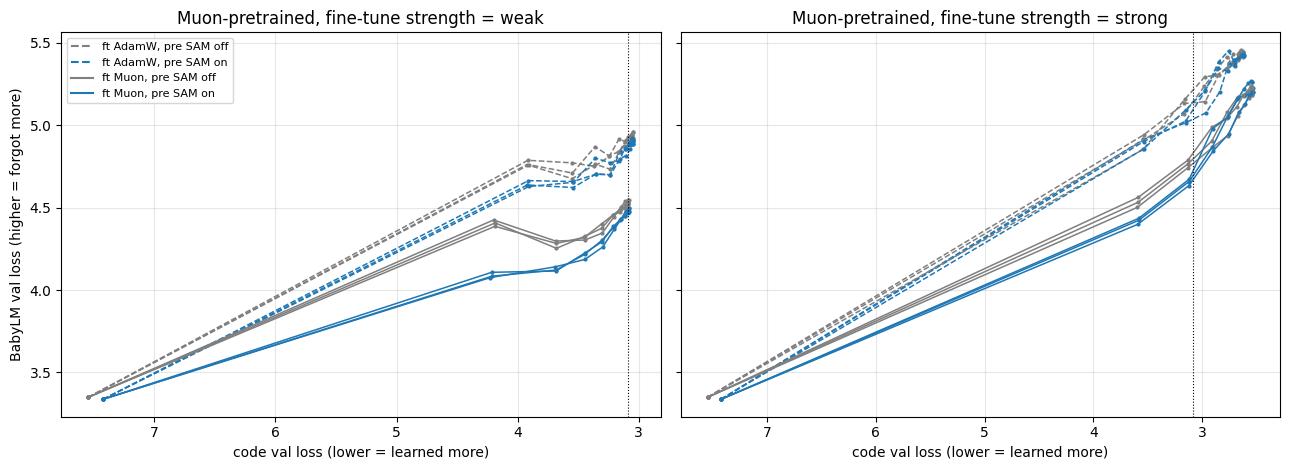

저장: /kaggle/working/exp_llm_muon_ftmuon


In [7]:
# ============ 셀 7: 같은 Muon 사전학습 모델 — AdamW로 파인튜닝(L2) vs Muon으로 파인튜닝(L3) ============
def parse(curves, ft_name):
    out = []
    for key, cv in curves.items():
        lr, s, pre = key.split('|')
        out.append(dict(ft=ft_name, lr=float(lr), seed=int(s), pre=pre, curve=cv))
    return out

ALL = parse(L2_CURVES, 'AdamW') + parse(CURVES, 'Muon')
lr_rank = {lr: i for i, lr in enumerate(sorted({r['lr'] for r in ALL}))}
COMMON = max(min(p['code'] for p in r['curve']) for r in ALL)     # 24개 run이 모두 도달한 코드 loss

for r in ALL:
    cv = r['curve']
    r.update(strength=['weak', 'strong'][lr_rank[r['lr']]],
             code_after=cv[-1]['code'], forgetting=cv[-1]['baby'] - cv[0]['baby'],
             forgetting_at_common=baby_at(cv, COMMON) - cv[0]['baby'])
cmp = pd.DataFrame([{k: v for k, v in r.items() if k != 'curve'} for r in ALL])
cmp.to_csv(f'{OUT}/compare_L2_L3.csv', index=False)

print(f'===== 파인튜닝 옵티마이저 비교 (공통 기준점: 코드 loss {COMMON:.3f}) =====')
print('strength: weak = 보조 AdamW lr 1e-4 쪽, strong = 3.33e-4 쪽')
display(cmp.groupby(['strength', 'ft', 'pre'])[['code_after', 'forgetting', 'forgetting_at_common']].mean().round(4))

print('\n===== 핵심: 같은 코드 loss 지점에서의 망각 (사전학습 SAM 끔 기준) =====')
for st in ['weak', 'strong']:
    a = cmp[(cmp.strength == st) & (cmp.ft == 'AdamW') & (cmp.pre == 'pre_off')].forgetting_at_common.mean()
    m = cmp[(cmp.strength == st) & (cmp.ft == 'Muon') & (cmp.pre == 'pre_off')].forgetting_at_common.mean()
    print(f'  [{st}] Muon→AdamW {a:.4f}  vs  Muon→Muon {m:.4f}   (비율 {m/a:.3f}, 1보다 작으면 같은 옵티마이저가 덜 잊음)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, st in zip(axes, ['weak', 'strong']):
    for r in ALL:
        if r['strength'] != st: continue
        cv = r['curve']
        ax.plot([p['code'] for p in cv], [p['baby'] for p in cv],
                color='tab:blue' if r['pre'] == 'pre_sam' else 'tab:gray',
                ls='-' if r['ft'] == 'Muon' else '--', marker='o', ms=2, lw=1.1)
    ax.axvline(COMMON, color='k', ls=':', lw=0.8); ax.invert_xaxis(); ax.grid(alpha=0.3)
    ax.set_title(f'Muon-pretrained, fine-tune strength = {st}')
    ax.set_xlabel('code val loss (lower = learned more)')
axes[0].set_ylabel('BabyLM val loss (higher = forgot more)')
from matplotlib.lines import Line2D
axes[0].legend(handles=[Line2D([], [], color='tab:gray', ls='--', label='ft AdamW, pre SAM off'),
                        Line2D([], [], color='tab:blue', ls='--', label='ft AdamW, pre SAM on'),
                        Line2D([], [], color='tab:gray', ls='-', label='ft Muon, pre SAM off'),
                        Line2D([], [], color='tab:blue', ls='-', label='ft Muon, pre SAM on')], fontsize=8)
plt.tight_layout(); plt.savefig(f'{OUT}/compare_L2_L3.png', dpi=150); plt.show()
print('저장:', OUT)